In [1]:
import fastf1 as f1
import pandas as pd
import requests

In [2]:
schedule = f1.get_event_schedule(2025)

req         WARNING 	DEFAULT CACHE ENABLED! (416.64 MB) C:\Users\dpsvn\AppData\Local\Temp\fastf1


In [3]:
schedule.head(10)

,RoundNumber,Country,Location,OfficialEventName,EventDate,EventName,EventFormat,Session1,Session1Date,Session1DateUtc,...,Session3,Session3Date,Session3DateUtc,Session4,Session4Date,Session4DateUtc,Session5,Session5Date,Session5DateUtc,F1ApiSupport
0,0,Bahrain,Sakhir,FORMULA 1 ARAMCO PRE-SEASON TESTING 2025,2025-02-28,Pre-Season Testing,testing,Practice 1,2025-02-26 10:00:00+03:00,2025-02-26 07:00:00,...,Practice 3,2025-02-28 10:00:00+03:00,2025-02-28 07:00:00,None,NaT,NaT,None,NaT,NaT,True
1,1,Australia,Melbourne,FORMULA 1 LOUIS VUITTON AUSTRALIAN GRAND PRIX ...,2025-03-16,Australian Grand Prix,conventional,Practice 1,2025-03-14 12:30:00+11:00,2025-03-14 01:30:00,...,Practice 3,2025-03-15 12:30:00+11:00,2025-03-15 01:30:00,Qualifying,2025-03-15 16:00:00+11:00,2025-03-15 05:00:00,Race,2025-03-16 15:00:00+11:00,2025-03-16 04:00:00,True
2,2,China,Shanghai,FORMULA 1 HEINEKEN CHINESE GRAND PRIX 2025,2025-03-23,Chinese Grand Prix,sprint_qualifying,Practice 1,2025-03-21 11:30:00+08:00,2025-03-21 03:30:00,...,Sprint,2025-03-22 11:00:00+08:00,2025-03-22 03:00:00,Qualifying,2025-03-22 15:00:00+08:00,2025-03-22 07:00:00,Race,2025-03-23 15:00:00+08:00,2025-03-23 07:00:00,True
3,3,Japan,Suzuka,FORMULA 1 LENOVO JAPANESE GRAND PRIX 2025,2025-04-06,Japanese Grand Prix,conventional,Practice 1,2025-04-04 11:30:00+09:00,2025-04-04 02:30:00,...,Practice 3,2025-04-05 11:30:00+09:00,2025-04-05 02:30:00,Qualifying,2025-04-05 15:00:00+09:00,2025-04-05 06:00:00,Race,2025-04-06 14:00:00+09:00,2025-04-06 05:00:00,True
4,4,Bahrain,Sakhir,FORMULA 1 GULF AIR BAHRAIN GRAND PRIX 2025,2025-04-13,Bahrain Grand Prix,conventional,Practice 1,2025-04-11 14:30:00+03:00,2025-04-11 11:30:00,...,Practice 3,2025-04-12 15:30:00+03:00,2025-04-12 12:30:00,Qualifying,2025-04-12 19:00:00+03:00,2025-04-12 16:00:00,Race,2025-04-13 18:00:00+03:00,2025-04-13 15:00:00,True
5,5,Saudi Arabia,Jeddah,FORMULA 1 STC SAUDI ARABIAN GRAND PRIX 2025,2025-04-20,Saudi Arabian Grand Prix,conventional,Practice 1,2025-04-18 16:30:00+03:00,2025-04-18 13:30:00,...,Practice 3,2025-04-19 16:30:00+03:00,2025-04-19 13:30:00,Qualifying,2025-04-19 20:00:00+03:00,2025-04-19 17:00:00,Race,2025-04-20 20:00:00+03:00,2025-04-20 17:00:00,True
6,6,United States,Miami Gardens,FORMULA 1 CRYPTO.COM MIAMI GRAND PRIX 2025,2025-05-04,Miami Grand Prix,sprint_qualifying,Practice 1,2025-05-02 12:30:00-04:00,2025-05-02 16:30:00,...,Sprint,2025-05-03 12:00:00-04:00,2025-05-03 16:00:00,Qualifying,2025-05-03 16:00:00-04:00,2025-05-03 20:00:00,Race,2025-05-04 16:00:00-04:00,2025-05-04 20:00:00,True
7,7,Italy,Imola,FORMULA 1 AWS GRAN PREMIO DEL MADE IN ITALY E ...,2025-05-18,Emilia Romagna Grand Prix,conventional,Practice 1,2025-05-16 13:30:00+02:00,2025-05-16 11:30:00,...,Practice 3,2025-05-17 12:30:00+02:00,2025-05-17 10:30:00,Qualifying,2025-05-17 16:00:00+02:00,2025-05-17 14:00:00,Race,2025-05-18 15:00:00+02:00,2025-05-18 13:00:00,True
8,8,Monaco,Monaco,FORMULA 1 TAG HEUER GRAND PRIX DE MONACO 2025,2025-05-25,Monaco Grand Prix,conventional,Practice 1,2025-05-23 13:30:00+02:00,2025-05-23 11:30:00,...,Practice 3,2025-05-24 12:30:00+02:00,2025-05-24 10:30:00,Qualifying,2025-05-24 16:00:00+02:00,2025-05-24 14:00:00,Race,2025-05-25 15:00:00+02:00,2025-05-25 13:00:00,True
9,9,Spain,Barcelona,FORMULA 1 ARAMCO GRAN PREMIO DE ESPAÑA 2025,2025-06-01,Spanish Grand Prix,conventional,Practice 1,2025-05-30 13:30:00+02:00,2025-05-30 11:30:00,...,Practice 3,2025-05-31 12:30:00+02:00,2025-05-31 10:30:00,Qualifying,2025-05-31 16:00:00+02:00,2025-05-31 14:00:00,Race,2025-06-01 15:00:00+02:00,2025-06-01 13:00:00,True


In [4]:
import requests
import pandas as pd

dfs = []

for season in range(2018, 2025):

    offset = 0

    while True:

        url = (
            f"https://api.jolpi.ca/ergast/f1/"
            f"{season}/results.json?limit=100&offset={offset}"
        )

        data = requests.get(url).json()

        races = data["MRData"]["RaceTable"]["Races"]

        if len(races) == 0:
            break

        for race in races:

            for result in race["Results"]:

                dfs.append({
                    "season": season,
                    "round": int(race["round"]),
                    "race_name": race["raceName"],
                    "race_date": race["date"],
                    "driver_id": result["Driver"]["driverId"],
                    "driver": f"{result['Driver']['givenName']} {result['Driver']['familyName']}",
                    "constructor": result["Constructor"]["name"],
                    "grid": int(result["grid"]),
                    "position": pd.to_numeric(result["position"], errors="coerce"),
                    "points": float(result["points"]),
                    "status": result["status"]
                })

        offset += 100

df_results = pd.DataFrame(dfs)

In [5]:
df_results.shape

(2979, 11)

In [6]:
df_results.head(20)

,season,round,race_name,race_date,driver_id,driver,constructor,grid,position,points,status
0,2018,1,Australian Grand Prix,2018-03-25,vettel,Sebastian Vettel,Ferrari,3,1,25.0,Finished
1,2018,1,Australian Grand Prix,2018-03-25,hamilton,Lewis Hamilton,Mercedes,1,2,18.0,Finished
2,2018,1,Australian Grand Prix,2018-03-25,raikkonen,Kimi Räikkönen,Ferrari,2,3,15.0,Finished
3,2018,1,Australian Grand Prix,2018-03-25,ricciardo,Daniel Ricciardo,Red Bull,8,4,12.0,Finished
4,2018,1,Australian Grand Prix,2018-03-25,alonso,Fernando Alonso,McLaren,10,5,10.0,Finished
5,2018,1,Australian Grand Prix,2018-03-25,max_verstappen,Max Verstappen,Red Bull,4,6,8.0,Finished
6,2018,1,Australian Grand Prix,2018-03-25,hulkenberg,Nico Hülkenberg,Renault,7,7,6.0,Finished
7,2018,1,Australian Grand Prix,2018-03-25,bottas,Valtteri Bottas,Mercedes,15,8,4.0,Finished
8,2018,1,Australian Grand Prix,2018-03-25,vandoorne,Stoffel Vandoorne,McLaren,11,9,2.0,Finished
9,2018,1,Australian Grand Prix,2018-03-25,sainz,Carlos Sainz,Renault,9,10,1.0,Finished


In [7]:
df_results = df_results.sort_values(
    ["driver_id", "race_date"]
)

In [8]:
df_results.head(20)

,season,round,race_name,race_date,driver_id,driver,constructor,grid,position,points,status
1155,2020,16,Sakhir Grand Prix,2020-12-06,aitken,Jack Aitken,Williams,17,16,0.0,Finished
433,2019,1,Australian Grand Prix,2019-03-17,albon,Alexander Albon,Toro Rosso,13,14,0.0,+1 Lap
448,2019,2,Bahrain Grand Prix,2019-03-31,albon,Alexander Albon,Toro Rosso,12,9,2.0,Finished
469,2019,3,Chinese Grand Prix,2019-04-14,albon,Alexander Albon,Toro Rosso,0,10,1.0,+1 Lap
490,2019,4,Azerbaijan Grand Prix,2019-04-28,albon,Alexander Albon,Toro Rosso,11,11,0.0,+1 Lap
510,2019,5,Spanish Grand Prix,2019-05-12,albon,Alexander Albon,Toro Rosso,11,11,0.0,Finished
527,2019,6,Monaco Grand Prix,2019-05-26,albon,Alexander Albon,Toro Rosso,10,8,4.0,Finished
558,2019,7,Canadian Grand Prix,2019-06-09,albon,Alexander Albon,Toro Rosso,13,19,0.0,Collision damage
574,2019,8,French Grand Prix,2019-06-23,albon,Alexander Albon,Toro Rosso,11,15,0.0,+1 Lap
594,2019,9,Austrian Grand Prix,2019-06-30,albon,Alexander Albon,Toro Rosso,18,15,0.0,+1 Lap


In [9]:
df_results["avg_points_last3"] = (
    df_results.groupby("driver_id")["points"]
    .transform(
        lambda x: x.shift(1).rolling(3, min_periods=1).mean()
    )
)

In [10]:
df_results.head(20)

,season,round,race_name,race_date,driver_id,driver,constructor,grid,position,points,status,avg_points_last3
1155,2020,16,Sakhir Grand Prix,2020-12-06,aitken,Jack Aitken,Williams,17,16,0.0,Finished,NaN
433,2019,1,Australian Grand Prix,2019-03-17,albon,Alexander Albon,Toro Rosso,13,14,0.0,+1 Lap,NaN
448,2019,2,Bahrain Grand Prix,2019-03-31,albon,Alexander Albon,Toro Rosso,12,9,2.0,Finished,0.000000
469,2019,3,Chinese Grand Prix,2019-04-14,albon,Alexander Albon,Toro Rosso,0,10,1.0,+1 Lap,1.000000
490,2019,4,Azerbaijan Grand Prix,2019-04-28,albon,Alexander Albon,Toro Rosso,11,11,0.0,+1 Lap,1.000000
510,2019,5,Spanish Grand Prix,2019-05-12,albon,Alexander Albon,Toro Rosso,11,11,0.0,Finished,1.000000
527,2019,6,Monaco Grand Prix,2019-05-26,albon,Alexander Albon,Toro Rosso,10,8,4.0,Finished,0.333333
558,2019,7,Canadian Grand Prix,2019-06-09,albon,Alexander Albon,Toro Rosso,13,19,0.0,Collision damage,1.333333
574,2019,8,French Grand Prix,2019-06-23,albon,Alexander Albon,Toro Rosso,11,15,0.0,+1 Lap,1.333333
594,2019,9,Austrian Grand Prix,2019-06-30,albon,Alexander Albon,Toro Rosso,18,15,0.0,+1 Lap,1.333333


In [11]:
df_results["points"] = pd.to_numeric(df_results["points"])

In [12]:
import requests
import time

def get_json(url, retries=5):
    for _ in range(retries):
        response = requests.get(url)

        if response.status_code == 200:
            return response.json()

        if response.status_code == 429:
            time.sleep(2)
            continue

        print("Error:", response.status_code, url)
        return None

    print("Failed after retries:", url)
    return None

In [13]:
import requests
import pandas as pd
import time

def safe_get(url, retries=3, delay=1.0):
    for attempt in range(retries):
        try:
            response = requests.get(url, timeout=10)
            if response.status_code == 200 and response.text.strip():
                return response.json()
            print(f"  Empty/bad response ({response.status_code}) for {url}")
        except Exception as e:
            print(f"  Attempt {attempt+1} failed: {e}")
        time.sleep(delay * (attempt + 1))  # backoff
    return None

rows = []

for season in range(2018, 2025):
    print(f"\nFetching season {season}...")
    
    races_url = f"https://api.jolpi.ca/ergast/f1/{season}.json"
    result = safe_get(races_url)
    
    if not result:
        print(f"  Skipping season {season} — no data")
        continue

    races  = result["MRData"]["RaceTable"]["Races"]
    rounds = [int(r["round"]) for r in races]

    for rnd in rounds:
        if rnd == 1:
            # No previous round — all teams start at 0
            rows.append({
                "season":                season,
                "round":                 rnd,
                "constructor":           "ALL",
                "constructor_id":        "ALL",
                "points_before_race":    0,
                "constructor_pts_per_race": 0,
            })
            continue

        prev_round = rnd - 1
        url = (
            f"https://api.jolpi.ca/ergast/f1/"
            f"{season}/{prev_round}/constructorstandings.json"
        )

        data = safe_get(url)

        if not data:
            print(f"  Skipping {season} R{rnd} — failed after retries")
            continue

        lists = data["MRData"]["StandingsTable"]["StandingsLists"]
        if not lists:
            print(f"  No standings for {season} R{prev_round}")
            continue

        standings = lists[0]["ConstructorStandings"]

        for team in standings:
            pts   = float(team["points"])
            races_done = rnd - 1

            rows.append({
                "season":                season,
                "round":                 rnd,
                "constructor":           team["Constructor"]["name"],
                "constructor_id":        team["Constructor"]["constructorId"],
                "points_before_race":    pts,
                "constructor_pts_per_race": pts / max(races_done, 1),
            })

        print(f"  ✓ Season {season} Round {rnd}")
        time.sleep(0.4)  # slightly longer delay to avoid rate limiting

constructor_standings = pd.DataFrame(rows)

print(constructor_standings.head(10))
print(f"\nShape: {constructor_standings.shape}")
print(f"Seasons: {constructor_standings['season'].unique()}")
print(f"NaN check:\n{constructor_standings.isna().sum()}")


Fetching season 2018...
  ✓ Season 2018 Round 2
  ✓ Season 2018 Round 3
  ✓ Season 2018 Round 4
  ✓ Season 2018 Round 5
  ✓ Season 2018 Round 6
  ✓ Season 2018 Round 7
  ✓ Season 2018 Round 8
  ✓ Season 2018 Round 9
  ✓ Season 2018 Round 10
  ✓ Season 2018 Round 11
  ✓ Season 2018 Round 12
  ✓ Season 2018 Round 13
  ✓ Season 2018 Round 14
  ✓ Season 2018 Round 15
  ✓ Season 2018 Round 16
  ✓ Season 2018 Round 17
  ✓ Season 2018 Round 18
  ✓ Season 2018 Round 19
  ✓ Season 2018 Round 20
  ✓ Season 2018 Round 21

Fetching season 2019...
  ✓ Season 2019 Round 2
  ✓ Season 2019 Round 3
  ✓ Season 2019 Round 4
  ✓ Season 2019 Round 5
  ✓ Season 2019 Round 6
  ✓ Season 2019 Round 7
  ✓ Season 2019 Round 8
  ✓ Season 2019 Round 9
  ✓ Season 2019 Round 10
  ✓ Season 2019 Round 11
  ✓ Season 2019 Round 12
  ✓ Season 2019 Round 13
  ✓ Season 2019 Round 14
  ✓ Season 2019 Round 15
  ✓ Season 2019 Round 16
  ✓ Season 2019 Round 17
  ✓ Season 2019 Round 18
  ✓ Season 2019 Round 19
  ✓ Season 2019 

In [14]:
constructor_standings.head()

,season,round,constructor,constructor_id,points_before_race,constructor_pts_per_race
0,2018,1,ALL,ALL,0.0,0.0
1,2018,2,Ferrari,ferrari,40.0,40.0
2,2018,2,Mercedes,mercedes,22.0,22.0
3,2018,2,Red Bull,red_bull,20.0,20.0
4,2018,2,McLaren,mclaren,12.0,12.0


In [15]:
df_results = df_results.merge(
    constructor_standings[
        ["season","round","constructor", "points_before_race","constructor_pts_per_race"]
    ].rename(columns={"points": "constructor_points"}),
    on=["season","round","constructor"],
    how="left"
)

In [16]:
df_results.head()

,season,round,race_name,race_date,driver_id,driver,constructor,grid,position,points,status,avg_points_last3,points_before_race,constructor_pts_per_race
0,2020,16,Sakhir Grand Prix,2020-12-06,aitken,Jack Aitken,Williams,17,16,0.0,Finished,NaN,0.0,0.000000
1,2019,1,Australian Grand Prix,2019-03-17,albon,Alexander Albon,Toro Rosso,13,14,0.0,+1 Lap,NaN,NaN,NaN
2,2019,2,Bahrain Grand Prix,2019-03-31,albon,Alexander Albon,Toro Rosso,12,9,2.0,Finished,0.0,1.0,1.000000
3,2019,3,Chinese Grand Prix,2019-04-14,albon,Alexander Albon,Toro Rosso,0,10,1.0,+1 Lap,1.0,3.0,1.500000
4,2019,4,Azerbaijan Grand Prix,2019-04-28,albon,Alexander Albon,Toro Rosso,11,11,0.0,+1 Lap,1.0,4.0,1.333333


In [17]:
df_results = df_results.sort_values(
    ["driver_id", "race_date"]
)

In [18]:
df_results.head()

,season,round,race_name,race_date,driver_id,driver,constructor,grid,position,points,status,avg_points_last3,points_before_race,constructor_pts_per_race
0,2020,16,Sakhir Grand Prix,2020-12-06,aitken,Jack Aitken,Williams,17,16,0.0,Finished,NaN,0.0,0.000000
1,2019,1,Australian Grand Prix,2019-03-17,albon,Alexander Albon,Toro Rosso,13,14,0.0,+1 Lap,NaN,NaN,NaN
2,2019,2,Bahrain Grand Prix,2019-03-31,albon,Alexander Albon,Toro Rosso,12,9,2.0,Finished,0.0,1.0,1.000000
3,2019,3,Chinese Grand Prix,2019-04-14,albon,Alexander Albon,Toro Rosso,0,10,1.0,+1 Lap,1.0,3.0,1.500000
4,2019,4,Azerbaijan Grand Prix,2019-04-28,albon,Alexander Albon,Toro Rosso,11,11,0.0,+1 Lap,1.0,4.0,1.333333


In [19]:
df_results['avg_circuit_points'] =df_results.groupby(["driver_id", "race_name"])['points'].transform('mean')

In [20]:
df_results["grid"] = df_results["grid"].replace(0, 20)

In [21]:
df_results["QualiToRace"]=df_results["grid"]/df_results["position"]

In [22]:
df_results.head()

,season,round,race_name,race_date,driver_id,driver,constructor,grid,position,points,status,avg_points_last3,points_before_race,constructor_pts_per_race,avg_circuit_points,QualiToRace
0,2020,16,Sakhir Grand Prix,2020-12-06,aitken,Jack Aitken,Williams,17,16,0.0,Finished,NaN,0.0,0.000000,0.00,1.062500
1,2019,1,Australian Grand Prix,2019-03-17,albon,Alexander Albon,Toro Rosso,13,14,0.0,+1 Lap,NaN,NaN,NaN,0.25,0.928571
2,2019,2,Bahrain Grand Prix,2019-03-31,albon,Alexander Albon,Toro Rosso,12,9,2.0,Finished,0.0,1.0,1.000000,3.60,1.333333
3,2019,3,Chinese Grand Prix,2019-04-14,albon,Alexander Albon,Toro Rosso,20,10,1.0,+1 Lap,1.0,3.0,1.500000,0.50,2.000000
4,2019,4,Azerbaijan Grand Prix,2019-04-28,albon,Alexander Albon,Toro Rosso,11,11,0.0,+1 Lap,1.0,4.0,1.333333,1.50,1.000000


In [23]:
df_results.head()

,season,round,race_name,race_date,driver_id,driver,constructor,grid,position,points,status,avg_points_last3,points_before_race,constructor_pts_per_race,avg_circuit_points,QualiToRace
0,2020,16,Sakhir Grand Prix,2020-12-06,aitken,Jack Aitken,Williams,17,16,0.0,Finished,NaN,0.0,0.000000,0.00,1.062500
1,2019,1,Australian Grand Prix,2019-03-17,albon,Alexander Albon,Toro Rosso,13,14,0.0,+1 Lap,NaN,NaN,NaN,0.25,0.928571
2,2019,2,Bahrain Grand Prix,2019-03-31,albon,Alexander Albon,Toro Rosso,12,9,2.0,Finished,0.0,1.0,1.000000,3.60,1.333333
3,2019,3,Chinese Grand Prix,2019-04-14,albon,Alexander Albon,Toro Rosso,20,10,1.0,+1 Lap,1.0,3.0,1.500000,0.50,2.000000
4,2019,4,Azerbaijan Grand Prix,2019-04-28,albon,Alexander Albon,Toro Rosso,11,11,0.0,+1 Lap,1.0,4.0,1.333333,1.50,1.000000


In [24]:
df_results['status'].unique()

array(['Finished', '+1 Lap', 'Collision damage', 'Electronics',
       'Radiator', '+2 Laps', 'Mechanical', 'Collision', 'Hydraulics',
       'Retired', 'Lapped', 'Did not start', 'Gearbox', 'Exhaust',
       'Wheel', 'Accident', 'Engine', 'Brakes', 'Rear wing', 'Water pump',
       'Water pressure', 'Water leak', 'Withdrew', 'Puncture',
       'Power Unit', 'Wheel nut', 'Damage', 'Cooling system', 'Spun off',
       'Steering', 'Power loss', 'Transmission', 'Suspension',
       'Disqualified', '+3 Laps', 'Fuel pressure', 'Overheating',
       'Illness', 'Front wing', 'Oil leak', '+5 Laps', 'Undertray',
       'Tyre', 'Driveshaft', 'Turbo', 'Fuel leak', 'Fuel pump',
       'Electrical', 'Battery', 'Out of fuel', 'Debris', 'Vibrations',
       'Differential', '+6 Laps'], dtype=object)

In [25]:
finished_statuses = [
    "Finished",
    "+1 Lap",
    "+2 Laps",
    "+3 Laps",
    "+5 Laps",
    "+6 Laps",
    "Lapped"
]

df_results["dnf"] = ~df_results["status"].isin(finished_statuses)
df_results["dnf"] = df_results["dnf"].astype(int)

In [26]:
df_results = df_results.sort_values(["driver_id", "race_date"])

df_results["dnf_last5"] = (
    df_results.groupby("driver_id")["dnf"]
    .transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).sum()
    )
)

In [27]:
df_results.head(20)

,season,round,race_name,race_date,driver_id,driver,constructor,grid,position,points,status,avg_points_last3,points_before_race,constructor_pts_per_race,avg_circuit_points,QualiToRace,dnf,dnf_last5
0,2020,16,Sakhir Grand Prix,2020-12-06,aitken,Jack Aitken,Williams,17,16,0.0,Finished,NaN,0.0,0.000000,0.00,1.062500,0,NaN
1,2019,1,Australian Grand Prix,2019-03-17,albon,Alexander Albon,Toro Rosso,13,14,0.0,+1 Lap,NaN,NaN,NaN,0.25,0.928571,0,NaN
2,2019,2,Bahrain Grand Prix,2019-03-31,albon,Alexander Albon,Toro Rosso,12,9,2.0,Finished,0.000000,1.0,1.000000,3.60,1.333333,0,0.0
3,2019,3,Chinese Grand Prix,2019-04-14,albon,Alexander Albon,Toro Rosso,20,10,1.0,+1 Lap,1.000000,3.0,1.500000,0.50,2.000000,0,0.0
4,2019,4,Azerbaijan Grand Prix,2019-04-28,albon,Alexander Albon,Toro Rosso,11,11,0.0,+1 Lap,1.000000,4.0,1.333333,1.50,1.000000,0,0.0
5,2019,5,Spanish Grand Prix,2019-05-12,albon,Alexander Albon,Toro Rosso,11,11,0.0,Finished,1.000000,4.0,1.000000,0.80,1.000000,0,0.0
6,2019,6,Monaco Grand Prix,2019-05-26,albon,Alexander Albon,Toro Rosso,10,8,4.0,Finished,0.333333,6.0,1.200000,1.50,1.250000,0,0.0
7,2019,7,Canadian Grand Prix,2019-06-09,albon,Alexander Albon,Toro Rosso,13,19,0.0,Collision damage,1.333333,16.0,2.666667,1.50,0.684211,1,0.0
8,2019,8,French Grand Prix,2019-06-23,albon,Alexander Albon,Toro Rosso,11,15,0.0,+1 Lap,1.333333,17.0,2.428571,0.00,0.733333,0,1.0
9,2019,9,Austrian Grand Prix,2019-06-30,albon,Alexander Albon,Toro Rosso,18,15,0.0,+1 Lap,1.333333,17.0,2.125000,0.00,1.200000,0,1.0


In [28]:
df_results["positions_gained"] = (
    df_results["grid"] - df_results["position"]
)

In [29]:
circuit_overtaking = (
    df_results.groupby("race_name")["positions_gained"]
    .mean()
    .reset_index()
    .rename(
        columns={"positions_gained": "circuit_avg_positions_gained"}
    )
)

In [30]:
df_results=df_results.merge(
    circuit_overtaking[["race_name","circuit_avg_positions_gained"]],
    on="race_name",
    how="left"
)

In [31]:
df_results["dnf_last5"] = df_results["dnf_last5"].fillna(0)

In [32]:
df_results.head()

,season,round,race_name,race_date,driver_id,driver,constructor,grid,position,points,status,avg_points_last3,points_before_race,constructor_pts_per_race,avg_circuit_points,QualiToRace,dnf,dnf_last5,positions_gained,circuit_avg_positions_gained
0,2020,16,Sakhir Grand Prix,2020-12-06,aitken,Jack Aitken,Williams,17,16,0.0,Finished,NaN,0.0,0.000000,0.00,1.062500,0,0.0,1,0.000000
1,2019,1,Australian Grand Prix,2019-03-17,albon,Alexander Albon,Toro Rosso,13,14,0.0,+1 Lap,NaN,NaN,NaN,0.25,0.928571,0,0.0,-1,0.000000
2,2019,2,Bahrain Grand Prix,2019-03-31,albon,Alexander Albon,Toro Rosso,12,9,2.0,Finished,0.0,1.0,1.000000,3.60,1.333333,0,0.0,3,0.064286
3,2019,3,Chinese Grand Prix,2019-04-14,albon,Alexander Albon,Toro Rosso,20,10,1.0,+1 Lap,1.0,3.0,1.500000,0.50,2.000000,0,0.0,10,0.000000
4,2019,4,Azerbaijan Grand Prix,2019-04-28,albon,Alexander Albon,Toro Rosso,11,11,0.0,+1 Lap,1.0,4.0,1.333333,1.50,1.000000,0,0.0,0,0.025000


In [33]:
df_results.to_csv('train.csv',index='False')

In [34]:
df_results = df_results.sort_values(
    ["season", "driver_id", "round"]
)

df_results["avg_quali_season"] = (
    df_results.groupby(["season", "driver_id"])["grid"]
    .transform(
        lambda x: x.shift(1).expanding().mean()
    )
)

In [35]:
import numpy as np

# ── 1. Target variable ────────────────────────────────────────────
df_results['won'] = (df_results['position'] == 1).astype(int)

# ── 2. Fill NaN in rolling features ──────────────────────────────

# avg_points_last3 — use 0 for first races (no history = no points)
df_results['avg_points_last3'] = df_results['avg_points_last3'].fillna(0)

# constructor_pts_per_race — use 0 for round 1
df_results['constructor_pts_per_race'] = df_results['constructor_pts_per_race'].fillna(0)
df_results['points_before_race'] = df_results['points_before_race'].fillna(0)

# avg_circuit_points — use driver's general avg_points_last3 as fallback
df_results['avg_circuit_points'] = df_results['avg_circuit_points'].fillna(
    df_results['avg_points_last3']
)

# circuit_avg_positions_gained — use 0 if no history
df_results['circuit_avg_positions_gained'] = (
    df_results['circuit_avg_positions_gained'].fillna(0)
)

# dnf_last5 — 0 means no recent DNFs, safe default
df_results['dnf_last5'] = df_results['dnf_last5'].fillna(0)

# ── 3. Verify no NaN left in features ─────────────────────────────
FEATURES = [
    'avg_points_last3',
    'constructor_pts_per_race',
    'avg_circuit_points',
    'dnf_last5',
    'circuit_avg_positions_gained',
    'grid',
]

print("NaN check after filling:")
print(df_results[FEATURES].isna().sum())

print(f"\nTotal rows:       {len(df_results)}")
print(f"Rows with won=1:  {df_results['won'].sum()}")
print(f"Unique seasons:   {df_results['season'].nunique()}")
print(f"Unique drivers:   {df_results['driver_id'].nunique()}")
print(f"Unique circuits:  {df_results['race_name'].nunique()}")

# ── 4. Sanity checks ──────────────────────────────────────────────

# Check class balance
total_races = df_results.groupby(['season', 'round']).ngroups

print(f"\nTotal races in dataset: {total_races}")
print(f"Winners recorded:       {df_results['won'].sum()}")
print(f"Should be equal ↑↑")

# Check grid range
print(f"\nGrid range: {df_results['grid'].min()} – {df_results['grid'].max()}")

# Check constructor_pts_per_race looks right
print("\nConstructor pts per race sample (Mercedes 2021):")

print(
    df_results[
        (df_results['constructor'] == 'Mercedes') &
        (df_results['season'] == 2021)
    ][['round', 'points_before_race', 'constructor_pts_per_race']]
    .head(10)
)

# ── 5. Handle pit lane starts (grid = 0) ─────────────────────────

max_grid = (
    df_results.groupby(['season', 'round'])['grid']
    .transform('max')
)

df_results['grid'] = df_results['grid'].replace(0, np.nan)
df_results['grid'] = df_results['grid'].fillna(max_grid + 1)

NaN check after filling:
avg_points_last3                0
constructor_pts_per_race        0
avg_circuit_points              0
dnf_last5                       0
circuit_avg_positions_gained    0
grid                            0
dtype: int64

Total rows:       2979
Rows with won=1:  149
Unique seasons:   7
Unique drivers:   40
Unique circuits:  36

Total races in dataset: 149
Winners recorded:       149
Should be equal ↑↑

Grid range: 1 – 20

Constructor pts per race sample (Mercedes 2021):
     round  points_before_race  constructor_pts_per_race
279      1                 0.0                  0.000000
280      2                41.0                 41.000000
281      3                60.0                 30.000000
282      4               101.0                 33.666667
283      5               141.0                 35.250000
284      6               148.0                 29.600000
285      7               148.0                 24.666667
286      8               178.0                 2

In [36]:
df_results['avg_quali_season'] = df_results['avg_quali_season'].fillna(df_results['grid'])

In [37]:
df_results = df_results.sort_values(
    ["season", "driver_id", "round"]
)

df_results["avg_posi_season"] = (
    df_results.groupby(["season", "driver_id"])["position"]
    .transform(
        lambda x: x.shift(1).expanding().mean()
    )
)

In [38]:
df_results['avg_posi_season'] = df_results['avg_posi_season'].fillna(df_results['position'])

In [39]:
df_results["QualiToPos"]=df_results["avg_quali_season"]/df_results["avg_posi_season"]

In [40]:
df_results.isna().sum()

season                          0
round                           0
race_name                       0
race_date                       0
driver_id                       0
driver                          0
constructor                     0
grid                            0
position                        0
points                          0
status                          0
avg_points_last3                0
points_before_race              0
constructor_pts_per_race        0
avg_circuit_points              0
QualiToRace                     0
dnf                             0
dnf_last5                       0
positions_gained                0
circuit_avg_positions_gained    0
avg_quali_season                0
won                             0
avg_posi_season                 0
QualiToPos                      0
dtype: int64

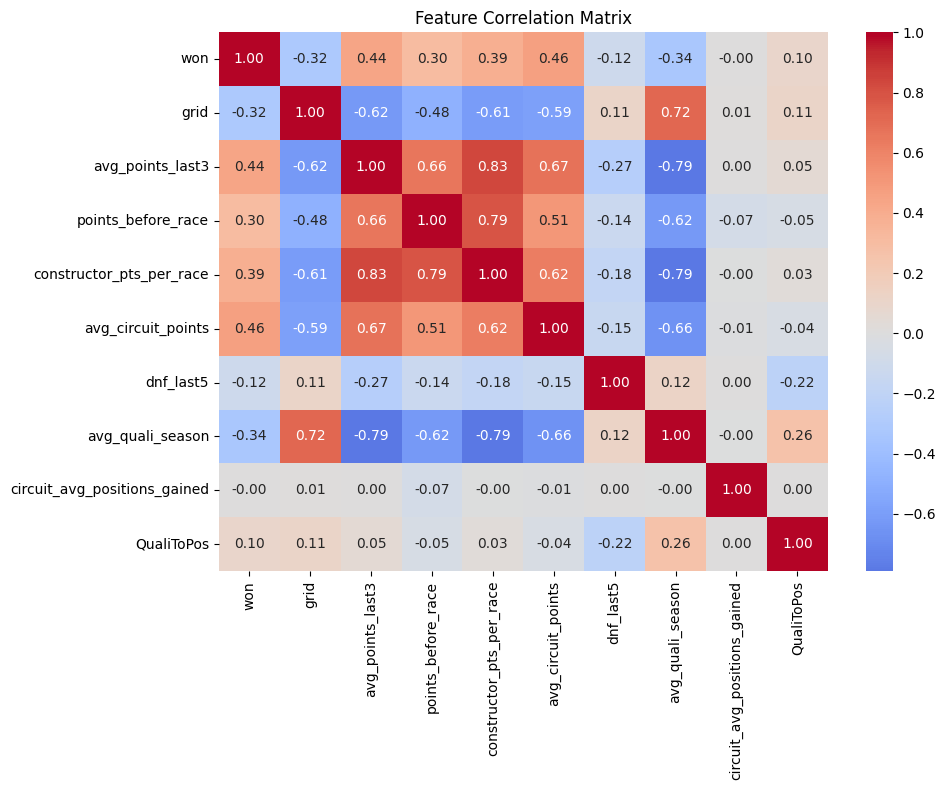

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_cols = [
    "won",
    "grid",
    "avg_points_last3",
    "points_before_race",
    "constructor_pts_per_race",
    "avg_circuit_points",
    "dnf_last5",
    "avg_quali_season",
    "circuit_avg_positions_gained",
    "QualiToPos",
]

corr_matrix = df_results[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

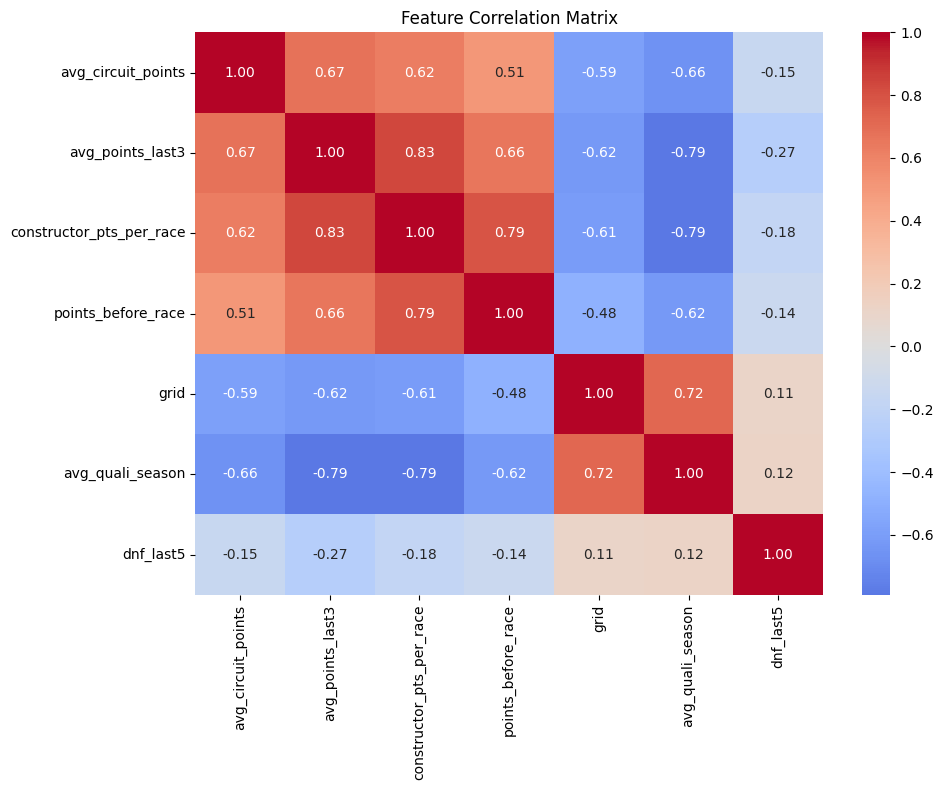

In [42]:
FEATURES = [
    'avg_circuit_points',       # 0.46 ← keep, strongest
    'avg_points_last3',         # 0.44 ← keep
    'constructor_pts_per_race', # 0.39 ← keep
    'points_before_race',       # 0.30 ← keep
    'grid',                     # -0.32 ← keep (strong, just negative)
    'avg_quali_season',         # -0.34 ← keep (strong, just negative)
    'dnf_last5',                # -0.12 ← keep (small but logical)
    # 'QualiToPos',             # 0.10 ← test with and without
    # 'circuit_avg_positions_gained'  # DROP — zero signal
]

import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df_results[FEATURES].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

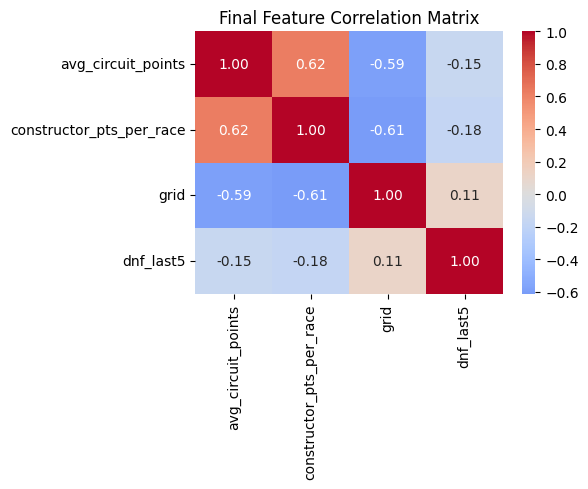

                          avg_circuit_points  constructor_pts_per_race  \
avg_circuit_points                  1.000000                  0.624567   
constructor_pts_per_race            0.624567                  1.000000   
grid                               -0.585089                 -0.611936   
dnf_last5                          -0.147400                 -0.176666   

                              grid  dnf_last5  
avg_circuit_points       -0.585089  -0.147400  
constructor_pts_per_race -0.611936  -0.176666  
grid                      1.000000   0.113956  
dnf_last5                 0.113956   1.000000  


In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

FINAL_FEATURES = [
    'avg_circuit_points',
    'constructor_pts_per_race',
    'grid',
    'dnf_last5',
]

corr = df_results[FINAL_FEATURES].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Final Feature Correlation Matrix')
plt.tight_layout()
plt.show()

print(corr)

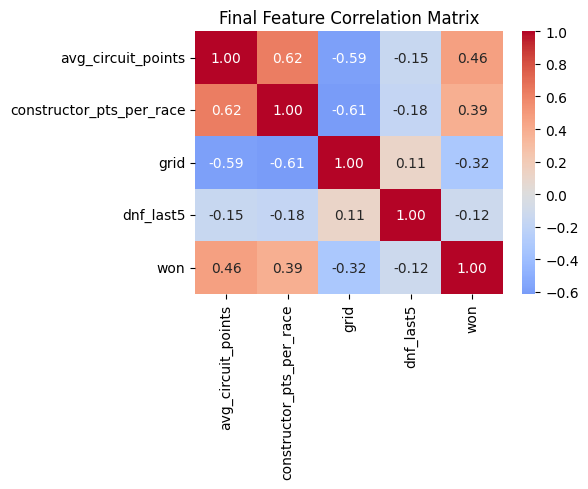

                          avg_circuit_points  constructor_pts_per_race  \
avg_circuit_points                  1.000000                  0.624567   
constructor_pts_per_race            0.624567                  1.000000   
grid                               -0.585089                 -0.611936   
dnf_last5                          -0.147400                 -0.176666   
won                                 0.464674                  0.385683   

                              grid  dnf_last5       won  
avg_circuit_points       -0.585089  -0.147400  0.464674  
constructor_pts_per_race -0.611936  -0.176666  0.385683  
grid                      1.000000   0.113956 -0.321345  
dnf_last5                 0.113956   1.000000 -0.116606  
won                      -0.321345  -0.116606  1.000000  


In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

FINAL_FEATURES = [
    'avg_circuit_points',
    'constructor_pts_per_race',
    'grid',
    'dnf_last5',
]

corr = df_results[FINAL_FEATURES].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Final Feature Correlation Matrix')
plt.tight_layout()
plt.show()

print(corr)

In [47]:
import xgboost as xgb
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score

FEATURES = [
    'avg_circuit_points',
    'constructor_pts_per_race',
    'grid',
    'dnf_last5',
]

# Target
df_results['won'] = (df_results['position'] == 1).astype(int)

# Fill any remaining NaN
df_results['dnf_last5'] = df_results['dnf_last5'].fillna(0)
df_results['avg_circuit_points'] = df_results['avg_circuit_points'].fillna(0)

# ── Time-based split — NEVER random for time series ──────────────
train = df_results[df_results['season'] <= 2022]
val   = df_results[df_results['season'] == 2023]
test  = df_results[df_results['season'] == 2024]

X_train, y_train = train[FEATURES], train['won']
X_val,   y_val   = val[FEATURES],   val['won']
X_test,  y_test  = test[FEATURES],  test['won']

# ── Model ─────────────────────────────────────────────────────────
model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=19,     # 1 winner per 20 drivers
    eval_metric='logloss',
    early_stopping_rounds=20,
    random_state=42,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50,
)

# ── Evaluate ──────────────────────────────────────────────────────
test['pred_prob'] = model.predict_proba(X_test)[:, 1]

# ROC-AUC
auc = roc_auc_score(y_test, test['pred_prob'])
print(f"ROC-AUC: {auc:.4f}")

# Top-N accuracy — most meaningful metric for F1 prediction
def top_n_accuracy(group, n):
    ranked = group.nlargest(n, 'pred_prob')
    return ranked['won'].max()

for n in [1, 3, 5]:
    acc = test.groupby(['season', 'round']).apply(top_n_accuracy, n=n).mean()
    print(f"Top-{n} accuracy: {acc:.2%}")

# Feature importance
importance = pd.Series(
    model.feature_importances_,
    index=FEATURES
).sort_values(ascending=False)
print(f"\nFeature Importance:\n{importance}")

[0]	validation_0-logloss:0.65919
[50]	validation_0-logloss:0.16852
[100]	validation_0-logloss:0.11881
[150]	validation_0-logloss:0.09920
[200]	validation_0-logloss:0.08732
[250]	validation_0-logloss:0.08120
[299]	validation_0-logloss:0.07551
ROC-AUC: 0.9145
Top-1 accuracy: 50.00%
Top-3 accuracy: 75.00%
Top-5 accuracy: 87.50%

Feature Importance:
grid                        0.566857
avg_circuit_points          0.243194
constructor_pts_per_race    0.110322
dnf_last5                   0.079626
dtype: float32


C:\Users\dpsvn\AppData\Local\Temp\ipykernel_5384\3980492388.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['pred_prob'] = model.predict_proba(X_test)[:, 1]
C:\Users\dpsvn\AppData\Local\Temp\ipykernel_5384\3980492388.py:61: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc = test.groupby(['season', 'round']).apply(top_n_accuracy, n=n).mean()
C:\Users\dpsvn\AppData\Local\Temp\ipykernel_5384\3980492388.py:61: FutureWarning: DataFrameGroupBy.apply operate

In [48]:
# Compare train vs test performance
train['pred_prob'] = model.predict_proba(X_train)[:, 1]

train_auc = roc_auc_score(y_train, train['pred_prob'])
test_auc  = roc_auc_score(y_test,  test['pred_prob'])

print(f"Train ROC-AUC: {train_auc:.4f}")
print(f"Test  ROC-AUC: {test_auc:.4f}")
print(f"Gap:           {train_auc - test_auc:.4f}")

# Gap > 0.05 = overfitting
# Gap < 0.05 = well generalised

Train ROC-AUC: 0.9971
Test  ROC-AUC: 0.9145
Gap:           0.0826


C:\Users\dpsvn\AppData\Local\Temp\ipykernel_5384\2598914792.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['pred_prob'] = model.predict_proba(X_train)[:, 1]


In [49]:
model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=3,           # reduce from 4 → shallower trees
    learning_rate=0.03,    # slower learning → less memorization
    subsample=0.7,         # use 70% of rows per tree (was 0.8)
    colsample_bytree=0.7,  # use 70% of features per tree (was 0.8)
    scale_pos_weight=19,
    
    # XGBoost regularization params
    reg_alpha=0.1,         # L1 regularization
    reg_lambda=2.0,        # L2 regularization (was default 1.0)
    min_child_weight=5,    # minimum samples in leaf (was 1)
    gamma=0.1,             # minimum loss reduction to split
    
    eval_metric='logloss',
    early_stopping_rounds=30,
    random_state=42,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50,
)

# Re-evaluate
train['pred_prob'] = model.predict_proba(X_train)[:, 1]
test['pred_prob']  = model.predict_proba(X_test)[:, 1]

train_auc = roc_auc_score(y_train, train['pred_prob'])
test_auc  = roc_auc_score(y_test,  test['pred_prob'])

print(f"Train ROC-AUC: {train_auc:.4f}")
print(f"Test  ROC-AUC: {test_auc:.4f}")
print(f"Gap:           {train_auc - test_auc:.4f}")

for n in [1, 3, 5]:
    acc = test.groupby(['season', 'round']).apply(
        lambda g: g.nlargest(n, 'pred_prob')['won'].max()
    ).mean()
    print(f"Top-{n} accuracy: {acc:.2%}")

[0]	validation_0-logloss:0.67434
[50]	validation_0-logloss:0.28109
[100]	validation_0-logloss:0.19755
[150]	validation_0-logloss:0.17099
[200]	validation_0-logloss:0.15354
[250]	validation_0-logloss:0.14058
[300]	validation_0-logloss:0.12813
[350]	validation_0-logloss:0.12043
[400]	validation_0-logloss:0.11446
[450]	validation_0-logloss:0.11031
[472]	validation_0-logloss:0.11005
Train ROC-AUC: 0.9852
Test  ROC-AUC: 0.9233
Gap:           0.0620
Top-1 accuracy: 58.33%
Top-3 accuracy: 75.00%
Top-5 accuracy: 87.50%


C:\Users\dpsvn\AppData\Local\Temp\ipykernel_5384\17929203.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['pred_prob'] = model.predict_proba(X_train)[:, 1]
C:\Users\dpsvn\AppData\Local\Temp\ipykernel_5384\17929203.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['pred_prob']  = model.predict_proba(X_test)[:, 1]
C:\Users\dpsvn\AppData\Local\Temp\ipykernel_5384\17929203.py:38: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a futu

In [50]:
model = xgb.XGBClassifier(
    n_estimators=1000,      # give it more room
    max_depth=3,            
    learning_rate=0.01,     # slower — was 0.03
    subsample=0.65,         # slightly less — was 0.7
    colsample_bytree=0.65,  # slightly less — was 0.7
    scale_pos_weight=19,
    reg_alpha=0.5,          # stronger L1 — was 0.1
    reg_lambda=3.0,         # stronger L2 — was 2.0
    min_child_weight=8,     # higher — was 5
    gamma=0.2,              # higher — was 0.1
    eval_metric='logloss',
    early_stopping_rounds=40,
    random_state=42,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100,
)

train['pred_prob'] = model.predict_proba(X_train)[:, 1]
test['pred_prob']  = model.predict_proba(X_test)[:, 1]

train_auc = roc_auc_score(y_train, train['pred_prob'])
test_auc  = roc_auc_score(y_test,  test['pred_prob'])

print(f"Train ROC-AUC: {train_auc:.4f}")
print(f"Test  ROC-AUC: {test_auc:.4f}")
print(f"Gap:           {train_auc - test_auc:.4f}")

for n in [1, 3, 5]:
    acc = test.groupby(['season', 'round']).apply(
        lambda g: g.nlargest(n, 'pred_prob')['won'].max()
    ).mean()
    print(f"Top-{n} accuracy: {acc:.2%}")

[0]	validation_0-logloss:0.68696
[100]	validation_0-logloss:0.35833
[200]	validation_0-logloss:0.24808
[300]	validation_0-logloss:0.20266
[400]	validation_0-logloss:0.17769
[500]	validation_0-logloss:0.16328
[600]	validation_0-logloss:0.15348
[700]	validation_0-logloss:0.14318
[800]	validation_0-logloss:0.13661
[900]	validation_0-logloss:0.12874
[999]	validation_0-logloss:0.12326
Train ROC-AUC: 0.9819
Test  ROC-AUC: 0.9301
Gap:           0.0517
Top-1 accuracy: 58.33%
Top-3 accuracy: 75.00%
Top-5 accuracy: 91.67%


C:\Users\dpsvn\AppData\Local\Temp\ipykernel_5384\107922044.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['pred_prob'] = model.predict_proba(X_train)[:, 1]
C:\Users\dpsvn\AppData\Local\Temp\ipykernel_5384\107922044.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['pred_prob']  = model.predict_proba(X_test)[:, 1]
C:\Users\dpsvn\AppData\Local\Temp\ipykernel_5384\107922044.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a f

In [59]:
import requests
import pandas as pd

def get_2025_results():
    rows = []
    offset = 0
    limit = 100

    while True:
        url = (
            f"https://api.jolpi.ca/ergast/f1/2025/results.json"
            f"?limit={limit}&offset={offset}"
        )

        data = requests.get(url).json()

        races = data["MRData"]["RaceTable"]["Races"]

        if not races:
            break

        for race in races:
            for result in race["Results"]:
                rows.append({
                    "season": 2025,
                    "round": int(race["round"]),
                    "race_name": race["raceName"],
                    "race_date": race["date"],
                    "driver_id": result["Driver"]["driverId"],
                    "driver": f"{result['Driver']['givenName']} {result['Driver']['familyName']}",
                    "constructor": result["Constructor"]["name"],
                    "constructor_id": result["Constructor"]["constructorId"],
                    "grid": int(result["grid"]),
                    "position": int(result["position"]),
                    "points": float(result["points"]),
                    "status": result["status"],
                    "won": int(result["position"] == "1")
                })

        total = int(data["MRData"]["total"])
        offset += limit

        if offset >= total:
            break

    return pd.DataFrame(rows)

df_2025 = get_2025_results()

print(f"Rows: {len(df_2025)}")
print(f"Rounds completed: {df_2025['round'].nunique()}")
print(df_2025.groupby('round')['race_name'].first())

Rows: 479
Rounds completed: 24
round
1         Australian Grand Prix
2            Chinese Grand Prix
3           Japanese Grand Prix
4            Bahrain Grand Prix
5      Saudi Arabian Grand Prix
6              Miami Grand Prix
7     Emilia Romagna Grand Prix
8             Monaco Grand Prix
9            Spanish Grand Prix
10          Canadian Grand Prix
11          Austrian Grand Prix
12           British Grand Prix
13           Belgian Grand Prix
14         Hungarian Grand Prix
15             Dutch Grand Prix
16           Italian Grand Prix
17        Azerbaijan Grand Prix
18         Singapore Grand Prix
19     United States Grand Prix
20       Mexico City Grand Prix
21         São Paulo Grand Prix
22         Las Vegas Grand Prix
23             Qatar Grand Prix
24         Abu Dhabi Grand Prix
Name: race_name, dtype: object


In [60]:
df_2025.shape

(479, 13)

In [61]:
import numpy as np

def build_2025_features(df_2025, df_historical):
    """
    df_historical = your 2018-2024 training dataframe
    df_2025       = raw 2025 results fetched above
    """
    rows = []
    
    completed_rounds = sorted(df_2025['round'].unique())
    
    for rnd in completed_rounds:
        race = df_2025[df_2025['round'] == rnd]
        race_name = race['race_name'].iloc[0]
        
        for _, driver_row in race.iterrows():
            driver_id    = driver_row['driver_id']
            constructor  = driver_row['constructor']
            constructor_id = driver_row['constructor_id']
            
            # ── 1. avg_circuit_points ─────────────────────────────
            # Driver's avg points at this circuit from historical data
            circuit_history = df_historical[
                (df_historical['driver_id'] == driver_id) &
                (df_historical['race_name'] == race_name)
            ]['points']
            
            avg_circuit_pts = circuit_history.mean() if len(circuit_history) > 0 else 0
            
            # ── 2. constructor_pts_per_race ───────────────────────
            # Constructor points in 2025 before this round
            if rnd == 1:
                constructor_pts_per_race = 0
            else:
                prev_rounds = df_2025[
                    (df_2025['round'] < rnd) &
                    (df_2025['constructor_id'] == constructor_id)
                ]
                total_pts  = prev_rounds['points'].sum()
                races_done = rnd - 1
                constructor_pts_per_race = total_pts / races_done
            
            # ── 3. grid ───────────────────────────────────────────
            grid = driver_row['grid']
            if grid == 0:  # pit lane start
                grid = 20
            
            # ── 4. dnf_last5 ──────────────────────────────────────
            prev_5 = df_2025[
                (df_2025['driver_id'] == driver_id) &
                (df_2025['round'] < rnd)
            ].tail(5)
            
            if len(prev_5) == 0:
                # Fall back to last 5 races of 2024
                prev_5_hist = df_historical[
                    (df_historical['driver_id'] == driver_id) &
                    (df_historical['season'] == 2024)
                ].tail(5)
                dnf_last5 = prev_5_hist['dnf'].mean() if len(prev_5_hist) > 0 else 0
            else:
                dnf_last5 = (prev_5['status'] != 'Finished').astype(int).mean()
            
            rows.append({
                'season':                  2025,
                'round':                   rnd,
                'race_name':               race_name,
                'driver_id':               driver_id,
                'driver':                  driver_row['driver'],
                'constructor':             constructor,
                'grid':                    grid,
                'position':                driver_row['position'],
                'won':                     driver_row['won'],
                'avg_circuit_points':      avg_circuit_pts,
                'constructor_pts_per_race':constructor_pts_per_race,
                'dnf_last5':              dnf_last5,
            })
    
    return pd.DataFrame(rows)

df_2025_features = build_2025_features(df_2025, df_results)
print(df_2025_features.head())
print(f"\nNaN check:\n{df_2025_features[FEATURES].isna().sum()}")

   season  round              race_name       driver_id  \
0    2025      1  Australian Grand Prix          norris   
1    2025      1  Australian Grand Prix  max_verstappen   
2    2025      1  Australian Grand Prix         russell   
3    2025      1  Australian Grand Prix       antonelli   
4    2025      1  Australian Grand Prix           albon   

                  driver constructor  grid  position  won  avg_circuit_points  \
0           Lando Norris     McLaren     1         1    1                8.25   
1         Max Verstappen    Red Bull     3         2    0                9.60   
2         George Russell    Mercedes     4         3    0                3.75   
3  Andrea Kimi Antonelli    Mercedes    16         4    0                0.00   
4        Alexander Albon    Williams     6         5    0                0.25   

   constructor_pts_per_race  dnf_last5  
0                       0.0        0.0  
1                       0.0        0.0  
2                       0.0        

In [62]:
import joblib
from sklearn.metrics import roc_auc_score



FEATURES = [
    'avg_circuit_points',
    'constructor_pts_per_race',
    'grid',
    'dnf_last5',
]

# Fill any NaN
df_2025_features['avg_circuit_points']       = df_2025_features['avg_circuit_points'].fillna(0)
df_2025_features['constructor_pts_per_race'] = df_2025_features['constructor_pts_per_race'].fillna(0)
df_2025_features['dnf_last5']               = df_2025_features['dnf_last5'].fillna(0)

X_2025 = df_2025_features[FEATURES]
df_2025_features['pred_prob'] = model.predict_proba(X_2025)[:, 1]

# ── Per race predictions ──────────────────────────────────────────
print("\n── Per Race Predictions ──────────────────────────────────")
for rnd in sorted(df_2025_features['round'].unique()):
    race = df_2025_features[df_2025_features['round'] == rnd].copy()
    race_name = race['race_name'].iloc[0]
    
    predicted = race.nlargest(1, 'pred_prob').iloc[0]
    actual    = race[race['won'] == 1].iloc[0]
    correct   = "✓" if predicted['driver_id'] == actual['driver_id'] else "✗"
    
    # Top 3 predicted
    top3 = race.nlargest(3, 'pred_prob')['driver_id'].tolist()
    in_top3 = "✓" if actual['driver_id'] in top3 else "✗"
    
    print(f"R{rnd:02d} {race_name:<30} "
          f"Predicted: {predicted['driver']:<15} "
          f"Actual: {actual['driver']:<15} "
          f"Top1:{correct} Top3:{in_top3}")

# ── Overall metrics ───────────────────────────────────────────────
print("\n── 2025 Season Metrics ───────────────────────────────────")

auc = roc_auc_score(
    df_2025_features['won'],
    df_2025_features['pred_prob']
)
print(f"ROC-AUC: {auc:.4f}")

for n in [1, 3, 5]:
    acc = df_2025_features.groupby('round').apply(
        lambda g: g.nlargest(n, 'pred_prob')['won'].max()
    ).mean()
    print(f"Top-{n} accuracy: {acc:.2%}")

# ── Show predicted vs actual per race ─────────────────────────────
print("\n── Predicted Probabilities per Race ─────────────────────")
for rnd in sorted(df_2025_features['round'].unique()):
    race = df_2025_features[df_2025_features['round'] == rnd].copy()
    print(f"\nRound {rnd} — {race['race_name'].iloc[0]}")
    print(
        race[['driver', 'grid', 'avg_circuit_points', 'pred_prob', 'won']]
        .sort_values('pred_prob', ascending=False)
        .head(5)
        .to_string(index=False)
    )


── Per Race Predictions ──────────────────────────────────
R01 Australian Grand Prix          Predicted: Lando Norris    Actual: Lando Norris    Top1:✓ Top3:✓
R02 Chinese Grand Prix             Predicted: Lando Norris    Actual: Oscar Piastri   Top1:✗ Top3:✓
R03 Japanese Grand Prix            Predicted: Max Verstappen  Actual: Max Verstappen  Top1:✓ Top3:✓
R04 Bahrain Grand Prix             Predicted: Charles Leclerc Actual: Oscar Piastri   Top1:✗ Top3:✓
R05 Saudi Arabian Grand Prix       Predicted: Max Verstappen  Actual: Oscar Piastri   Top1:✗ Top3:✓
R06 Miami Grand Prix               Predicted: Max Verstappen  Actual: Oscar Piastri   Top1:✗ Top3:✗
R07 Emilia Romagna Grand Prix      Predicted: Max Verstappen  Actual: Max Verstappen  Top1:✓ Top3:✓
R08 Monaco Grand Prix              Predicted: Lando Norris    Actual: Lando Norris    Top1:✓ Top3:✓
R09 Spanish Grand Prix             Predicted: Max Verstappen  Actual: Oscar Piastri   Top1:✗ Top3:✗
R10 Canadian Grand Prix            Predi

C:\Users\dpsvn\AppData\Local\Temp\ipykernel_5384\256517294.py:50: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc = df_2025_features.groupby('round').apply(
C:\Users\dpsvn\AppData\Local\Temp\ipykernel_5384\256517294.py:50: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc = df_2025_features.groupby('round').apply(
C:\Users\dpsvn\AppData\Local\Temp\ipykernel_5384\256517294.py:50: FutureWarning: DataFrameGroupBy.appl

In [63]:
import joblib

joblib.dump(model, "f1_winner_model.pkl")

['f1_winner_model.pkl']